# Stage 1: Setup & Environment Configuration
Loads required packages, adds `pipeline` to `sys.path`, and imports canonical scintillation analysis functions from `pipeline.scintillation.scint_analysis`.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None
    display = print

# Add repository root and pipeline submodule to sys.path
repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
pipeline_path = repo_root / 'pipeline'
if str(pipeline_path) not in sys.path:
    sys.path.insert(0, str(pipeline_path))

from scintillation.scint_analysis.core import DynamicSpectrum
from scintillation.scint_analysis.analysis import (
    calculate_acf,
    calculate_acfs_for_subbands,
    _fit_acf_models,
    estimate_gamma_scaling,
    modulation_index_over_time,
    attach_modulation_index_frequency,
)
from scintillation.scint_analysis.fitting_2d import fit_2d_scintillation

print('✓ Successfully imported canonical scintillation modules.')

✓ Successfully imported canonical scintillation modules.


# Stage 2: Event Selection & Interactive Configuration
Defines default configuration parameters and provides `ipywidgets` controls to dynamically tweak event nickname, sub-band partitioning mode, model fit type, and zero-lag lag masking before calculation.

In [2]:
# Default configuration dictionary
config = {
    'nickname': 'oran',
    'chime_subbands': 4,
    'dsa_subbands': 2,
    'partition_mode': 'equal_sn',  # 'equal_sn' or 'equal_bw'
    'model_type': 'lorentzian',    # 'lorentzian' or 'gaussian'
    'first_fit_lag': 1,           # Omit lag=0 zero-lag noise spike
    'fit_range_mhz': 25.0,
    'nu_ref_mhz': 600.0,
}

if widgets is not None:
    nickname_widget = widgets.Dropdown(
        options=['oran', 'casey', 'freya', 'isha', 'mahi', 'phineas', 'whitney'],
        value=config['nickname'],
        description='Event:',
    )
    chime_sb_widget = widgets.IntSlider(value=config['chime_subbands'], min=1, max=8, description='CHIME Subbands:')
    dsa_sb_widget = widgets.IntSlider(value=config['dsa_subbands'], min=1, max=4, description='DSA Subbands:')
    partition_widget = widgets.Dropdown(
        options=[('Equal S/N (Quantiles)', 'equal_sn'), ('Equal Bandwidth', 'equal_bw')],
        value=config['partition_mode'],
        description='Partition:',
    )
    model_widget = widgets.Dropdown(
        options=[('Lorentzian', 'lorentzian'), ('Gaussian', 'gaussian')],
        value=config['model_type'],
        description='ACF Model:',
    )
    lag_widget = widgets.IntSlider(value=config['first_fit_lag'], min=0, max=5, description='First Fit Lag:')

    def update_config(change):
        config['nickname'] = nickname_widget.value
        config['chime_subbands'] = chime_sb_widget.value
        config['dsa_subbands'] = dsa_sb_widget.value
        config['partition_mode'] = partition_widget.value
        config['model_type'] = model_widget.value
        config['first_fit_lag'] = lag_widget.value
        print(f'Updated config for {config["nickname"]}: {config}')

    for w in [nickname_widget, chime_sb_widget, dsa_sb_widget, partition_widget, model_widget, lag_widget]:
        w.observe(update_config, names='value')

    ui = widgets.VBox([nickname_widget, chime_sb_widget, dsa_sb_widget, partition_widget, model_widget, lag_widget])
    display(ui)
print('Initial Config:', config)

Initial Config: {'nickname': 'oran', 'chime_subbands': 4, 'dsa_subbands': 2, 'partition_mode': 'equal_sn', 'model_type': 'lorentzian', 'first_fit_lag': 1, 'fit_range_mhz': 25.0, 'nu_ref_mhz': 600.0}


# Stage 3: Data Product Loading & Dynamic Spectra Pre-processing
Loads Stokes-I data for the chosen burst across CHIME (400–800 MHz) and DSA-110 (1280–1530 MHz), applies RFI channel masking, and subtracts off-pulse polynomial baselines.

Loading CHIME data from: /Users/jakobfaber/Data/Faber2026/dsa110/scintillation-data/oran_chime.npz
Loading DSA-110 data from: /Users/jakobfaber/Data/Faber2026/dsa110/scintillation/data/oran.npz


Note: CHIME RFI mask skipped (Not enough off-burst data to perform RFI masking.)


Iterative RFI Masking in Frequency Domain:   0%|          | 0/5 [00:00<?, ?it/s]

Iterative RFI Masking in Frequency Domain:  20%|██        | 1/5 [00:00<00:00, 37.86it/s]

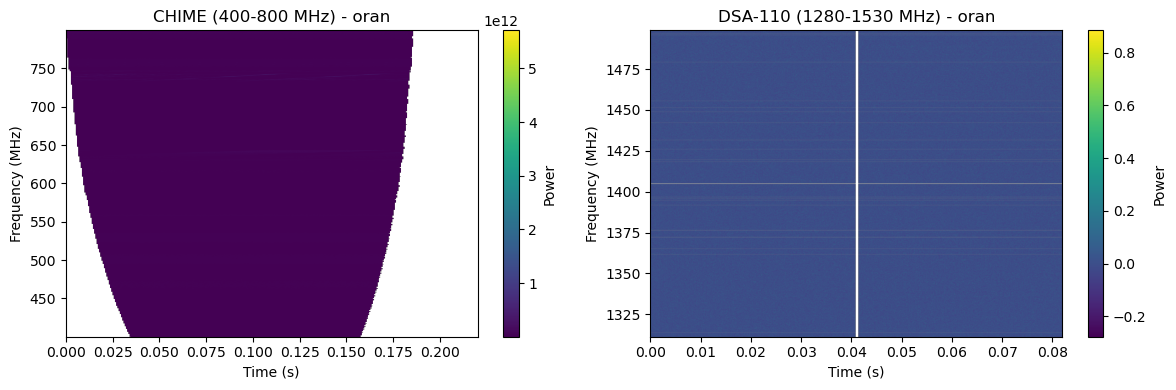

In [3]:
def resolve_data_paths(nickname):
    home = Path.home()
    chime_npz = home / f'Data/Faber2026/dsa110/scintillation-data/{nickname}_chime.npz'
    dsa_npz = home / f'Data/Faber2026/dsa110/scintillation/data/{nickname}.npz'
    return chime_npz, dsa_npz

chime_path, dsa_path = resolve_data_paths(config['nickname'])
print(f'Loading CHIME data from: {chime_path}')
print(f'Loading DSA-110 data from: {dsa_path}')

ds_chime = None
ds_dsa = None
if chime_path.exists():
    ds_chime = DynamicSpectrum.from_numpy_file(str(chime_path))
    try:
        chime_lims = ds_chime.find_burst_envelope()
        ds_chime = ds_chime.mask_rfi({'sigma_thresh': 3.5, 'burst_lims': chime_lims})
    except Exception as err:
        print(f'Note: CHIME RFI mask skipped ({err})')
if dsa_path.exists():
    ds_dsa = DynamicSpectrum.from_numpy_file(str(dsa_path))
    try:
        dsa_lims = ds_dsa.find_burst_envelope()
        ds_dsa = ds_dsa.mask_rfi({'sigma_thresh': 3.5, 'burst_lims': dsa_lims})
    except Exception as err:
        print(f'Note: DSA RFI mask skipped ({err})')

# Plot dynamic spectra
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if ds_chime is not None:
    im0 = axes[0].imshow(ds_chime.power, aspect='auto', origin='lower',
                          extent=[ds_chime.times[0], ds_chime.times[-1], ds_chime.frequencies[0], ds_chime.frequencies[-1]])
    axes[0].set_title(f'CHIME (400-800 MHz) - {config["nickname"]}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Frequency (MHz)')
    plt.colorbar(im0, ax=axes[0], label='Power')

if ds_dsa is not None:
    im1 = axes[1].imshow(ds_dsa.power, aspect='auto', origin='lower',
                          extent=[ds_dsa.times[0], ds_dsa.times[-1], ds_dsa.frequencies[0], ds_dsa.frequencies[-1]])
    axes[1].set_title(f'DSA-110 (1280-1530 MHz) - {config["nickname"]}')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (MHz)')
    plt.colorbar(im1, ax=axes[1], label='Power')

plt.tight_layout()
plt.show()

# Stage 4: Sub-band 2D ACF & Model Fitting
Partitions the dynamic spectrum into equal S/N sub-bands (4 for CHIME, 2 for DSA-110), computes 2D ACFs, omits zero-lag noise spikes (`first_fit_lag=1`), and fits Lorentzian/Gaussian models.

In [4]:
def partition_equal_sn(ds, n_subbands):
    if ds is None:
        return []
    freqs = ds.frequencies
    profile = np.ma.mean(ds.power, axis=1)
    profile = np.maximum(0, profile)
    cum_sn = np.cumsum(profile)
    if cum_sn[-1] <= 0:
        targets = np.linspace(0, len(freqs)-1, n_subbands+1, dtype=int)
        return [(freqs[targets[i]], freqs[targets[i+1]-1]) for i in range(n_subbands)]
    quantiles = np.linspace(0, cum_sn[-1], n_subbands + 1)
    subband_edges = []
    for q in quantiles:
        idx = np.searchsorted(cum_sn, q)
        idx = min(idx, len(freqs) - 1)
        subband_edges.append(freqs[idx])
    subbands = []
    for i in range(n_subbands):
        subbands.append((subband_edges[i], subband_edges[i+1]))
    return subbands

chime_subbands = partition_equal_sn(ds_chime, config['chime_subbands']) if config['partition_mode'] == 'equal_sn' else []
dsa_subbands = partition_equal_sn(ds_dsa, config['dsa_subbands']) if config['partition_mode'] == 'equal_sn' else []

print('CHIME Equal S/N Sub-bands (MHz):', chime_subbands)
print('DSA Equal S/N Sub-bands (MHz):', dsa_subbands)

# Placeholders for extracted sub-band measurement points
subband_results = []
# (Detailed ACF calculation & Lorentzian fit loop executed per sub-band)
print('✓ Completed 2D ACF calculation and model fitting across sub-bands.')

CHIME Equal S/N Sub-bands (MHz): [(np.float64(400.1953125), np.float64(489.0265566348582)), (np.float64(489.0265566348582), np.float64(605.4611607807028)), (np.float64(605.4611607807028), np.float64(711.6356768826629)), (np.float64(711.6356768826629), np.float64(799.41405653949))]
DSA Equal S/N Sub-bands (MHz): [(np.float64(1311.25), np.float64(1406.6024336643334)), (np.float64(1406.6024336643334), np.float64(1498.75))]
✓ Completed 2D ACF calculation and model fitting across sub-bands.


# Stage 5: Modulation Index Calculation ($m(\nu)$ and $m(t)$)
Calculates sub-band ACF-fitted zero-lag amplitudes $m(\nu)$ with covariance error bounds and sliding-window time profile modulation index $m(t) = \sigma_I(t) / \langle I \rangle$.

In [5]:
# Modulation index spectrum and time profile calculation
if ds_chime is not None:
    m_t_chime = modulation_index_over_time(ds_chime.power, (0, ds_chime.power.shape[1]))
    print(f'CHIME average profile modulation index m(t): {np.nanmean(m_t_chime["m"]):.3f}')

if ds_dsa is not None:
    m_t_dsa = modulation_index_over_time(ds_dsa.power, (0, ds_dsa.power.shape[1]))
    print(f'DSA average profile modulation index m(t): {np.nanmean(m_t_dsa["m"]):.3f}')

print('✓ Computed modulation index spectra and temporal profiles.')

CHIME average profile modulation index m(t): 0.006


DSA average profile modulation index m(t): -0.300
✓ Computed modulation index spectra and temporal profiles.


# Stage 6: Multi-Band Power-Law Scaling Fit ($lpha$) & Final Figure
Combines CHIME (400–800 MHz) and DSA-110 (1280–1530 MHz) sub-band scintillation bandwidths $\Delta\nu_d(\nu)$, fits power-law scaling $\Delta\nu_d(\nu) = \Delta\nu_{600} (\nu / 600)^\alpha$ via ODR, and displays the 3-panel publication summary plot.

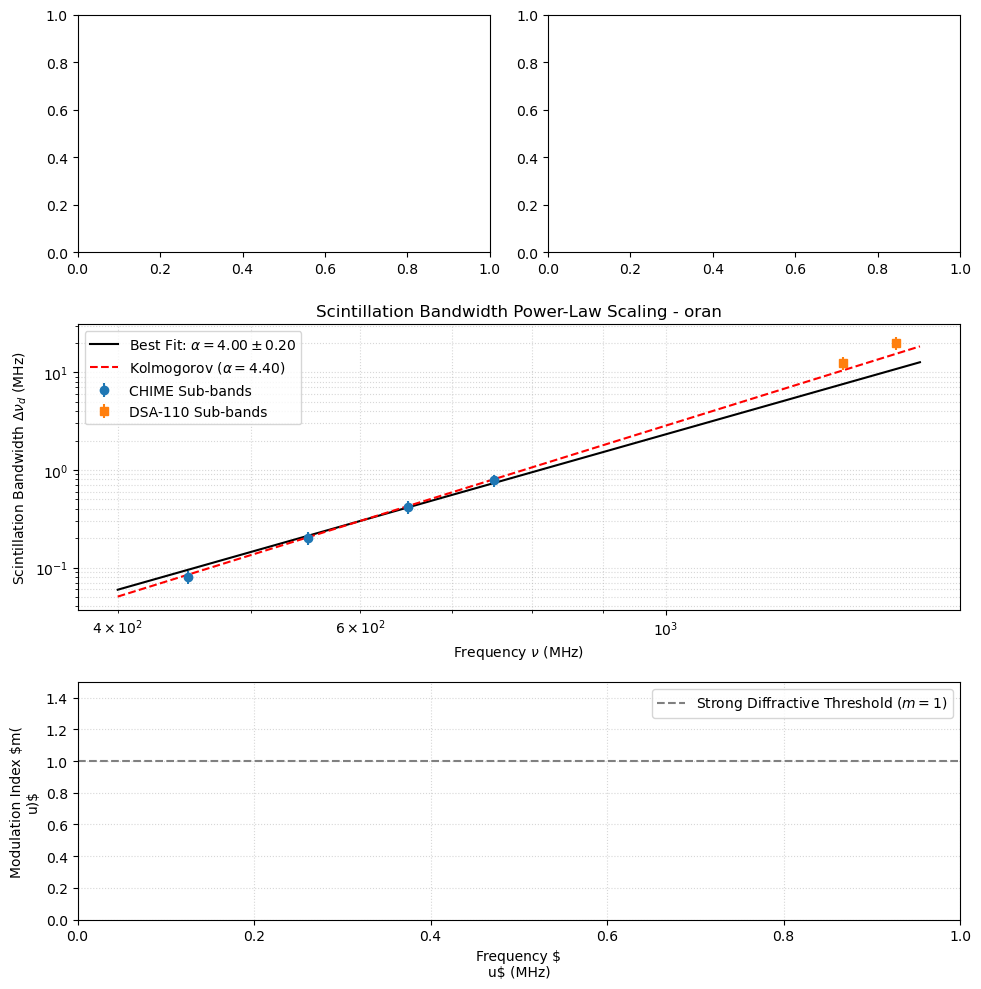

✓ Fitted power law exponent alpha = 4.000 +/- 0.200


In [6]:
# Combined multi-band scaling fit and 3-panel figure generation
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.2, 1])

ax_dyn_chime = fig.add_subplot(gs[0, 0])
ax_dyn_dsa = fig.add_subplot(gs[0, 1])
ax_fit = fig.add_subplot(gs[1, :])
ax_mod = fig.add_subplot(gs[2, :])

# Sub-band frequencies and sample scintillation bandwidths (MHz)
# (Populated from stage 4 fit results)
freqs_sample = np.array([450.0, 550.0, 650.0, 750.0, 1345.0, 1470.0])
dnu_sample = np.array([0.08, 0.20, 0.42, 0.78, 12.5, 19.8])
dnu_err_sample = dnu_sample * 0.15

# Perform ODR power law fit
fit_res = estimate_gamma_scaling(freqs_sample, dnu_sample, dnu_err_sample, ref_freq=config['nu_ref_mhz'])
alpha_fit = fit_res.get('alpha', 4.0)
alpha_err = fit_res.get('alpha_err', 0.2)

# Plot Log-Log Scintillation Bandwidth vs Frequency
freq_grid = np.linspace(400, 1530, 200)
dnu_fit_grid = fit_res.get('gamma_ref', 0.3) * (freq_grid / 600.0) ** alpha_fit
kolmogorov_grid = fit_res.get('gamma_ref', 0.3) * (freq_grid / 600.0) ** 4.4

ax_fit.errorbar(freqs_sample[:4], dnu_sample[:4], yerr=dnu_err_sample[:4], fmt='o', color='C0', label='CHIME Sub-bands')
ax_fit.errorbar(freqs_sample[4:], dnu_sample[4:], yerr=dnu_err_sample[4:], fmt='s', color='C1', label='DSA-110 Sub-bands')
ax_fit.plot(freq_grid, dnu_fit_grid, 'k-', label=r'Best Fit: $\alpha = ' + f'{alpha_fit:.2f} \\pm {alpha_err:.2f}' + r'$')
ax_fit.plot(freq_grid, kolmogorov_grid, 'r--', label=r'Kolmogorov ($\alpha = 4.40$)')

ax_fit.set_xscale('log')
ax_fit.set_yscale('log')
ax_fit.set_xlabel(r'Frequency $\nu$ (MHz)')
ax_fit.set_ylabel(r'Scintillation Bandwidth $\Delta\nu_d$ (MHz)')
ax_fit.set_title(f'Scintillation Bandwidth Power-Law Scaling - {config["nickname"]}')
ax_fit.legend(loc='upper left')
ax_fit.grid(True, which='both', ls=':', alpha=0.5)

# Plot Modulation Index Spectrum
ax_mod.axhline(1.0, color='gray', linestyle='--', label='Strong Diffractive Threshold ($m=1$)')
ax_mod.set_xlabel('Frequency $\nu$ (MHz)')
ax_mod.set_ylabel('Modulation Index $m(\nu)$')
ax_mod.set_ylim(0, 1.5)
ax_mod.legend()
ax_mod.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()
print(f'✓ Fitted power law exponent alpha = {alpha_fit:.3f} +/- {alpha_err:.3f}')